# Milestone 2 - Implementation Foundation
**Track B:** Fine-tuning an existing model with LoRA (Parameter-Efficient Fine-Tuning)
*   **Base Model:** `meta-llama/Llama-3.1-8B`
## What this notebook does
*   Loads and documents the LLaMA 3.1 8B tokenizer and runs diagonstics on ATIS prompts
*   Builds a custom dataset and collate function for supervised fine-tuning with prompt masking
*   Loads LLaMA 3.1 8B model and attaches LoRA adapters
*   Runs minimal fine-tuning smoke test
*   Explains the pipelines process in detail (for a summarized version look at `report.pdf` in the root of the zip file.)

## Before running this notebook:
*   HuggingFace account with approved access to `meta-llama/Llama-3.1-8B`. Create a new token and copy it. Provide token when prompted in the first cell.
*   Change Colab runtime to GPU (Runtime -> Change runtime type -> choose a GPU). I used A100 GPU
> NO file uploads to Google Colab session is necessary

## To run this notebook:
1. Run the first code cell (setup cell) and enter your token when prompted (DO NOT PRESS "Run all")
2. Click/select the second code cell of the notebook (under Section 1 - Load Data) so it is the focused cell
3. Click the down arrow next to the "Run all" button (in the top bar)
4. Select 'Run focused cells and all cells below'.
> If this process is not followed, a HuggingFace authenticaton error may occur. If an error does occur, ONLY rerun the code cell with the error and all cells below it.

## Outputs:
*   `loss_curve.png` and `smoke_test_log.txt` are saved under `results/` of the Google Colab session files.  

> It is NOT necessary to run `00_preprocessing.ipynb` before this notebook.

## 0) Setup
Libraries used:
*   `transformers` and `peft` for model loading and LORA
*   `bitsandbytes` for 4-bit quantization (to reduce memory use)
*   `torch` for training
*   `numpy` for tokenizer diagnostics
*   `matplotlib` for plotting

Input HuggingFace token in the cell below when prompted.

In [1]:
import os
import sys
import json
import random
import numpy as np
import urllib.request
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") # suppress warnings from HuggingFace for clean output

from huggingface_hub import login
from transformers import AutoTokenizer
from peft import get_peft_model, LoraConfig, TaskType

# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# provide HuggingFace token and log in
login()

!pip install -q transformers peft bitsandbytes accelerate

Using device: cuda


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.8 MB/s eta 0:00:00


## 1) Load Data
Downloads required files from GitHub if not already present in session, then loads data into memory  
**Files downloaded:**
*   `split_train.jsonl` - training question-SQL pairs
*   `split_dev.jsonl` - development question-SQL pairs used for validation during the smoke test
*   `schema_relational.txt` - relational schema format used as this project's baseline representation
*   `schema_create_table.txt`, `schema_json.txt`, `schema_nl.txt` - other schema formats to determine context length

The train and dev files were created in the `00_preprocessing.ipynb` notebook and the schema files were created manually.  

In [2]:
# Prompt Builder Functions (defined here so we don't have to upload prompt_builder.py script every session)

def load_schema(schema_path):
  """Load schema string from a .txt file."""
  with open(schema_path, "r") as f:
    return f.read().strip()

def build_prompt(question, schema):
  """Assemble a prompt from a question and schema string."""
  return(
      f"Translate the following question into SQL.\n\n"
      f"Schema:\n{schema}\n\n"
      f"Question: {question}\n\n"
      f"SQL:"
  )

> If the GitHub download for the schema and dataset files fail in the next cell, manually upload to you Colab session (Files icon -> Upload) and re-run. Files should be under `data/` and `schemas/` of the zip file. Don't upload the folders, upload only the files into the root of Colab files.

In [3]:
# My GitHub repository for this project
BASE_URL = "https://raw.githubusercontent.com/halleepham/text2sql-schema-representation/main"

# Dataset files created in preprocessing notebook
FILES = {
    "split_train.jsonl": f"{BASE_URL}/data/split_train.jsonl",
    "split_dev.jsonl": f"{BASE_URL}/data/split_dev.jsonl",
    "schema_relational.txt": f"{BASE_URL}/schemas/schema_relational.txt",
    "schema_create_table.txt": f"{BASE_URL}/schemas/schema_create_table.txt",
    "schema_json.txt": f"{BASE_URL}/schemas/schema_json.txt",
    "schema_nl.txt": f"{BASE_URL}/schemas/schema_nl.txt",
}

for filename, url in FILES.items():
  path = Path(filename)
  if not path.exists():
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, path)
    print(f"  Done.")
  else:
    print(f"{filename} already exists, skipping.")

# Load train and dev splits
train_data = []
with open("split_train.jsonl", "r") as f:
  for line in f:
    train_data.append(json.loads(line))

dev_data = []
with open("split_dev.jsonl", "r") as f:
  for line in f:
    dev_data.append(json.loads(line))

# Load schema (the baseline schema is the relational format)
schema = load_schema(Path("schema_relational.txt"))

print(f"\nNumber of train examples: {len(train_data)}")
print(f"Number of dev examples: {len(dev_data)}")
print(f"Baseline schema loaded: {len(schema)} characters")

  Done.
  Done.
  Done.
  Done.
  Done.
  Done.

Number of train examples: 4055
Number of dev examples: 436
Baseline schema loaded: 2061 characters


## 2) Tokenizer
*   The LLaMA 3.1 8B tokenizer is loaded directly from HuggingFace. Since this project is fine-tuning an existing model, I reuse its tokenizer (not training a new one).  
*   LLaMA's tokenizer has no padding token so I set it to the EOS token.

 ---

**Tokenizer details:**
*   **Type:** Byte-Pair Encoding (BPE)
*   **Implementation:** `SentencePiece` (HuggingFace `transformers` - `AutoTokenizer`)
*   **Why appropriate for this task:**
    *   Pre-trained on large corpus that includes code
    *   Handles subword tokenization (takes care of unknown words)

In [4]:
# Model name
MODEL_ID = "meta-llama/Llama-3.1-8B"

# Load tokenizer that was used to train the model
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Since LLaMA tokenizer does not have a pad token by default, set it to EOS token (for batching later)
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
  print(f"Set pad token to EOS token.")

print(f"\nTokenizer loaded: {MODEL_ID}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

print(f"\nSpecial tokens:")
print(f"  BOS (begin of text): {tokenizer.bos_token} (id: {tokenizer.bos_token_id})")
print(f"  EOS (end of text): {tokenizer.eos_token} (id: {tokenizer.eos_token_id})")
print(f"  PAD: {tokenizer.pad_token} (id: {tokenizer.pad_token_id})")

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Set pad token to EOS token.

Tokenizer loaded: meta-llama/Llama-3.1-8B
Vocabulary size: 128,000

Special tokens:
  BOS (begin of text): <|begin_of_text|> (id: 128000)
  EOS (end of text): <|end_of_text|> (id: 128001)
  PAD: <|end_of_text|> (id: 128001)


**Tokenizer Output Notes:**
*   **Vocabulary size:** 128,000
*   Significantly larger than GPT-2's (50,257). A larger vocab means more common words/subwords are represented as single tokens, reducing sequence length (good for long prompts like mine that contain fairly long database schema)
* The Meta LlaMA papers says that the `SentencePiece` tokenizer is tiktoken based with a much large vocab.



## 3) Tokenizer Diagnostics
Runs diagnostics on built prompts from full dev set to measure how the LLaMA tokenizer handles specific data.

### 3a) Diagnostics WITH relational schema

In [5]:
# Build prompts from dev set
prompts = [build_prompt(row["question"], schema) for row in dev_data]

# Tokenize the sample prompts to token IDs
encodings = [tokenizer.encode(p) for p in prompts]

# List of token count for each prompt
lengths = [len(e) for e in encodings]

# List of character count for each prompt
chars = [len(p) for p in prompts]

avg_tokens = np.mean(lengths)
avg_chars = np.mean(chars)
tokens_per_1k = (avg_tokens / avg_chars) * 1000
unk_rate = sum(1 for e in encodings for t in e if t == tokenizer.unk_token_id) / sum(lengths)

print(f"Number of prompts: {len(prompts)} prompts")
print(f"Avg tokens per prompt: {avg_tokens:.2f}")
print(f"Min tokens: {min(lengths)}")
print(f"Max tokens: {max(lengths)}")
print(f"Avg char per single token: {avg_chars/avg_tokens:.2f}")
print(f"Tokens per 1k chars: {avg_tokens:.2f} / {avg_chars:.2f} * 1000 = {tokens_per_1k:.2f}")
print(f"Unknown token rate: {unk_rate:.6f}")

Number of prompts: 436 prompts
Avg tokens per prompt: 505.10
Min tokens: 492
Max tokens: 531
Avg char per single token: 4.34
Tokens per 1k chars: 505.10 / 2193.19 * 1000 = 230.30
Unknown token rate: 0.000000


**Tokenizer Diagnostic Output Notes:**
*   505 token avg per prompt: the schema probably dominates prompt length, plus it is identical across all examples. Will look into metrics without schema in next section
*   Low variance (min 492, max 531): this confirms prompth length is driven by fixed schema (not question or SQL)
*   1 token ~ 4 chars: typical for BPE tokenization on mixed English and SQL text (https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them)
*   Unknown token rate of 0: BPE tokenizer can encode any character with its byte-level fallback.

### 3b) Diagnostics WITHOUT relational schema
Since the schema is the same for every prompt, it would be better to look at just the diagnostics for just the instruction + question + `SQL:`

In [6]:
# Build prompts with no schema
prompts_no_schema = [build_prompt(row["question"], "") for row in dev_data]

encodings_no_schema = [tokenizer.encode(p) for p in prompts_no_schema]
lengths_no_schema = [len(e) for e in encodings_no_schema]

avg_tokens_no_schema = np.mean(lengths_no_schema)

print(f"Avg tokens per prompt (no schema): {avg_tokens_no_schema:.2f}")
print(f"Min tokens (no schema): {min(lengths_no_schema)}")
print(f"Max tokens (no schema): {max(lengths_no_schema)}")

schema_tokens = avg_tokens - avg_tokens_no_schema
print(f"\nAvg tokens from schema alone: {schema_tokens:.2f} ({(schema_tokens/avg_tokens)*100:.1f}% of prompt)")

Avg tokens per prompt (no schema): 31.10
Min tokens (no schema): 18
Max tokens (no schema): 57

Avg tokens from schema alone: 474.00 (93.8% of prompt)


**Tokenizer Diagnostics (without schema) Output Notes:**
*   Avg 31 tokens without schema vs 505 tokens with schema
*   Schema accounts for ~94% of the prompt

### 3c) Example Encodings
Two question and SQL encodings and encoding for the relational schema format.

In [7]:
examples = [
    ("Question 1", dev_data[0]["question"]),
    ("SQL 1", dev_data[0]["sql"]),
    ("Question 2", dev_data[100]["question"]),
    ("SQL 2", dev_data[100]["sql"]),
    ("Schema (relational only)", schema)
]

for label, text in examples:
  tokens = tokenizer.convert_ids_to_tokens(tokenizer.encode(text))
  print(f"\n--{label}--")
  print(f"Text: {text}")
  print(f"\nTokens: {tokens[:100]}")  # only first 100 (so schema output isn't long)


--Question 1--
Text: list all the flights that fly into MKE

Tokens: ['<|begin_of_text|>', 'list', 'Ġall', 'Ġthe', 'Ġflights', 'Ġthat', 'Ġfly', 'Ġinto', 'ĠM', 'KE']

--SQL 1--
Text: SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT AS AIRPORTalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , CITY AS CITYalias0 , FLIGHT AS FLIGHTalias0 WHERE AIRPORTalias0.AIRPORT_CODE = "MKE" AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORTalias0.AIRPORT_CODE

Tokens: ['<|begin_of_text|>', 'SELECT', 'ĠDISTINCT', 'ĠFL', 'IGHT', 'alias', '0', '.F', 'LIGHT', '_ID', 'ĠFROM', 'ĠAIR', 'PORT', 'ĠAS', 'ĠAIR', 'PORT', 'alias', '0', 'Ġ,', 'ĠAIR', 'PORT', '_SERVICE', 'ĠAS', 'ĠAIR', 'PORT', '_SERVICE', 'alias', '0', 'Ġ,', 'ĠCITY', 'ĠAS', 'ĠCITY', 'alias', '0', 'Ġ,', 'ĠFL', 'IGHT', 'ĠAS', 'ĠFL', 'IGHT', 'alias', '0', 'ĠWHERE', 'ĠAIR', 'PORT', 'alias', '0', '.A', 'IR', 'PORT', '_CODE', 'Ġ=', 'Ġ"', 'M

**Encoding Output Notes:**
*   The natural language questions tokenize cleanly (`list`, `flights`, `arrive`)
*   Airport codes like `MKE` are split into two subword tokens `['M', 'KE']`
*   SQL aliases like `FLIGHTalias0` are split into subwords. The model must learn from context that these refer to specific tables, not from a single token.
*   Columns names in schema token like `aircraft_code` are split into `['air', 'craft', '_code']`
*   Compound column names are consistently split at underscores
*   `Ġ` prefix just indicates space before token
*   `Ċ` suffix indicates newline character (appears at then end of each schema line)

### 3d) Token Length by Schema Format
Computes average prompt token length across all four schema formats to determine the approporiate context length T for the data pipeline.

In [8]:
schema_files = {
    "relational": "schema_relational.txt",
    "create_table": "schema_create_table.txt",
    "json": "schema_json.txt",
    "natural_language": "schema_nl.txt"
}

max_schema_tokens = 0

for name, filename in schema_files.items():
  schema_str = load_schema(Path(filename))
  token_ids = tokenizer.encode(schema_str)
  token_count = len(token_ids)

  if token_count > max_schema_tokens:
    max_schema_tokens = token_count
  print(f"{name:15s}: {token_count} tokens")

print(f"\nMax schema tokens: {max_schema_tokens}")
print(f"Max prompt tokens (no schema): {max(lengths_no_schema)}")
print(f"Estimated max prompt length: {max_schema_tokens + max(lengths_no_schema)}")
print(f"Recommended context length: {2**int(np.ceil(np.log2(max_schema_tokens + max(lengths_no_schema))))}")

relational     : 475 tokens
create_table   : 824 tokens
json           : 809 tokens
natural_language: 830 tokens

Max schema tokens: 830
Max prompt tokens (no schema): 57
Estimated max prompt length: 887
Recommended context length: 1024


**Schema Encodings Output Notes:**
*   The natural language schema is the longest at 830 tokens
*   The max prompt length is 887 tokens. This is an estimate since question lengths are measured on the dev set only
*   Recommended context length T=1024. This was calculated by the next power of 2 over 887. This is so it safely acommodates all four schema formats with room for edge cases.
*   T = 1024 will be used as `allowed_max_length` (the max sequence length any example can be truncated to) in the next sections collate function

## 4) Data Pipeline
Builds the dataset and collate function for supevised fine-tuning.  

---

**Notes:**
*   The `TextToSQLDataset` class and `collate_sft_batch` function are adapted from the `InstructionDataset` and `collate_sft_batch` implementation in the `finetuning_for_instructions.ipynb` given in class.
*   The core masking logic and dynamic padding approach are reused directly.
*   Modifications include loading from JSONL instead of JSON, using `build_prompt()` (defined in the second cell of this notebook) instead of `format_alpaca_prompt()`, and appending the SQL target instead of an instruction response.

In [9]:
IGNORE_INDEX = -100
PAD_ID = tokenizer.pad_token_id
ALLOWED_MAX_LEN = 1024 # Justified by above section

class TextToSQLDataset(Dataset):
  """Dataset that stores raw question-SQL pairs. Tokenization happens in collate_fn."""

  def __init__(self, data):
    self.data = data  # list of dicts with question, sql, split keys

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.data[idx] # return raw dict

In [10]:
# This function is adapted from collate_sft_batch() in the finetuning_for_instruction.ipynb notebook from class
# Modfication: uses build_prompt() from prompt assembly and appends SQL as the target.
def collate_sft_batch(batch,
                      device=device,
                      pad_token_id=PAD_ID,
                      ignore_index=IGNORE_INDEX,
                      allowed_max_length=ALLOWED_MAX_LEN):
  """
  Create (input_ids, target_ids, prompt_lens) for supervised fine-tuning.

  Returns:
      input_ids:  LongTensor [B, T]
      target_ids: LongTensor [B, T] with -100 where loss should be ignored
      prompt_lens: LongTensor [B] length of prompt (so we can slice generated responses later)
  """

  texts = [] # full strings: prompt + sql
  prompt_lens = [] # token lengths of prompt-only part

  for entry in batch:
    prompt = build_prompt(entry["question"], schema)  # assemble prompt
    full = prompt + entry["sql"]  # append SQL as target
    texts.append(full)
    prompt_ids = tokenizer.encode(prompt) # tokenize prompt (without SQL) to get length (used later to know where to start loss mask)
    prompt_lens.append(len(prompt_ids)) # store prompt token length

  # Tokenize full sequences
  tokenized = [tokenizer.encode(t) for t in texts]

  # Dynamic padding (pad to longest sequence in batch add 1 for EOS token, capped at allowed_max_length)
  batch_max = min(max(len(ids) for ids in tokenized) + 1, allowed_max_length)

  input_ids_lst = []
  target_ids_lst = []

  for ids, p_len in zip(tokenized, prompt_lens):
    # Append EOS token then truncate to batch_max
    ids = (ids + [pad_token_id])[:batch_max]

    # Pad to batch_max
    pad_amount = batch_max - len(ids)
    ids = ids + [pad_token_id] * pad_amount

    # Shift to create targets: input is tokens 0..T-1, target is tokens 1..T (next token prediction)
    input_ids = ids[:-1]
    target_ids = ids[1:]

    # Mask prompt and padding positions in targets
    prompt_mask_len = min(p_len, len(target_ids)) # number of prompt tokens to mask
    target_ids[:prompt_mask_len] = [ignore_index] * prompt_mask_len # mask with -100
    target_ids = [ignore_index if t == pad_token_id else t for t in target_ids] # mask any remaining padding positions (so model is not penalized for not predicting PAD tokens)

    input_ids_lst.append(input_ids)
    target_ids_lst.append(target_ids)

  # convert all lists to tensors, move to GPU
  input_ids_tensor = torch.tensor(input_ids_lst, dtype=torch.long).to(device)
  target_ids_tensor = torch.tensor(target_ids_lst, dtype=torch.long).to(device)
  prompt_lens_tensor = torch.tensor(prompt_lens, dtype=torch.long).to(device)

  return input_ids_tensor, target_ids_tensor, prompt_lens_tensor

*   **Prompt masking**: prompt tokens are masked in `target_ids` so cross-entropy loss is computed only on SQL output tokens. This is so model is not penalized for what is generates during the prompt portion.
*   Padding tokens are also masked so model is not penalized for padding positions

## 5) DataLoaders
Wraps the dataset in PyTorch `DataLoader` objects for the train and dev splits. A small slice (100 examples) of the train split is used for the smoke test.

---
**Note:** The DataLoader setup pattern was taken from the `finetuning_for_instruction.ipynb` from class


In [11]:
BATCH_SIZE = 2
SMOKE_TEST_SIZE = 100

# Create datasets
train_dataset = TextToSQLDataset(train_data[:SMOKE_TEST_SIZE])
dev_dataset = TextToSQLDataset(dev_data)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    collate_fn = collate_sft_batch
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    collate_fn = collate_sft_batch
)

print(f"Train examples (smoke test): {len(train_dataset)}")
print(f"Dev examples: {len(dev_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Dev batches: {len(dev_loader)}")

Train examples (smoke test): 100
Dev examples: 436
Train batches: 50
Dev batches: 218


In [12]:
input_ids, target_ids, prompt_lens = next(iter(train_loader))
print(f"Tensor shapes:")
print(f"  input_ids: {input_ids.shape}")
print(f"  target_ids: {target_ids.shape}")
print(f"  prompt_lens: {prompt_lens.shape}")
print(f"\nFraction of target_ids masked to -100: {(target_ids == IGNORE_INDEX).float().mean():.3f}")

Tensor shapes:
  input_ids: torch.Size([2, 728])
  target_ids: torch.Size([2, 728])
  prompt_lens: torch.Size([2])

Fraction of target_ids masked to -100: 0.697


**DataLoader Output Notes:**
*   100 train examples -> 50 batches (with batch size = 2) for smoke test slice
*   436 dev examples -> 218 batches. Full dev set used for validation loss
*   Shapes for `input_ids` and `target_ids` are both `[B, T]`
*   69.7% percent of target positions are masked. The majority of positions are masked since the schema is most of the prompt length (~94%). The model only computes loss on the remaining ~30% which corresponds to the SQL output tokens.

## 6) Model Setup
Loads LLaMA 3.1 8B in 4-bit quantization and attaches LoRA adapters for parameter-efficent fine-tuning.  
**Base model:** `meta-llama/Llama-3.1-8B`  
**Quantization:** `bitsandbytes` (QLoRA approach) this reduces memory usage  
**Adaptation:** LoRA via `peft`. Only a small number of adapter parameters are trained, the base model weights remain frozen.

---
**Note:** Model loading used the HuggingFace `transformers` and `bitsandbytes` libraries. The QLoRA setup follows the approach described in Dettmers et al. (2023) "QLoRA: Efficient Finetuning of Quantized LLMs."

In [13]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

# 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type = "nf4",
    bnb_4bit_compute_dtype = torch.float16
)

# Load base model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_config,
    device_map = "auto"
)
model.config.use_cache = False  # disable KV cache (only used during inference not training)

# LoRA config
lora_config = LoraConfig(
    r = 8,
    lora_alpha = 16,
    target_modules = ["q_proj", "v_proj"],
    lora_dropout = 0.05,
    bias = "none",
    task_type = TaskType.CAUSAL_LM
)

# Attach LoRA adapters
model = get_peft_model(model, lora_config)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [14]:
# Print parameter counts
model.print_trainable_parameters()

# Display model architecture summary
print(f"\nArchitecture: LLaMA 3.1 8B (decoder only transformer)")
print(f"Layers: {model.config.num_hidden_layers}")
print(f"Heads: {model.config.num_attention_heads}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Dropout: {lora_config.lora_dropout}")
print(f"LoRA rank: {lora_config.r}")
print(f"LoRa alpha: {lora_config.lora_alpha}")
print(f"LoRA targets: {lora_config.target_modules}")

trainable params: 3,407,872 || all params: 8,033,669,120 || trainable%: 0.0424

Architecture: LLaMA 3.1 8B (decoder only transformer)
Layers: 32
Heads: 32
Hidden size: 4096
Dropout: 0.05
LoRA rank: 8
LoRa alpha: 16
LoRA targets: {'v_proj', 'q_proj'}


**Model Setup Output Notes:**
*   0.0424% of parameters are trainable, confirming base model is frozen and only LoRA adpater weights are trained.

## 7) Smoke Test
Runs a minimal fine-tuning loop on the 100-example train slice to verify pipeline works end to end.  
*   Optimizer: AdamW
*   Learning rate: 5e-5
*   Steps: 50 (one pass through 100 examples at batch size 2)
*   Hardware: A100 GPU

---
**Note:** `calc_loss_batch`, `eval_loss_loader`, and `train_sft_simple` are adapted from the equivalent functions in `finetuning_for_instruction.ipynb` notebook from class. Modifications include removing the text generation calls before and after training since inference is out of scope for Milestone 2.

### 7a) Define Loss Functions

In [15]:
import torch.nn.functional as F

def calc_loss_batch(model, input_ids, target_ids):
  """
  Compute cross-entropy loss on a single batch.
  Adapted from calc_loss_batch() in finetuning_for_instruction.ipynb notebook from class
  """

  logits = model(input_ids).logits  # forward pass -> [B, T, vocab_size]

  loss = F.cross_entropy(
      logits.view(-1, logits.size(-1)), # reshape to [B*T, vocab_size]
      target_ids.view(-1),  # reshape to [B*T] (one label per prediction)
      ignore_index=IGNORE_INDEX  # skip -100 positions (masked)
  )
  return loss

In [16]:
@torch.no_grad()
def eval_loss_loader(model, loader, max_batches=20):
  """
  Compute average loss over a DataLoader without updating weights.
  Adapted from eval_loss_loader in finetuning_for_instruction.ipynb notebook from class
  """
  model.eval()  # eval mode to disable dropout
  total_loss = 0.0
  n_batches = 0

  for i, (input_ids, target_ids, _) in enumerate(loader):
    if i >= max_batches:
      break
    total_loss += calc_loss_batch(model, input_ids, target_ids).item()
    n_batches += 1

  model.train() # put model back in training mode after eval

  return total_loss / n_batches if n_batches > 0 else float("nan")

In [17]:
def train_sft_simple(model, train_loader, dev_loader, epochs, lr, eval_every):
  """
  Minimal SFT training loop with train and val loss logging.
  Adapted from train_sft_simple() in finetuning_for_instruction.ipynb notebook from class
  """

  optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
  history = {"step": [], "train_loss": [], "val_loss": []}
  step = 0

  # Only 1 epoch for smoke test
  for epoch in range(epochs):
    model.train()

    for input_ids, target_ids, _ in train_loader:
      step += 1

      loss = calc_loss_batch(model, input_ids, target_ids)  # foward pass an loss computation
      optimizer.zero_grad() # clear gradients from previous step
      loss.backward() # computes gradients via backpropagation
      optimizer.step()  # updates the LoRA adapter weights using computed gradients

      if step % eval_every == 0:
        tr = eval_loss_loader(model, train_loader, max_batches=5)
        va = eval_loss_loader(model, dev_loader, max_batches=5)

        history["step"].append(step)
        history["train_loss"].append(tr)
        history["val_loss"].append(va)

        print(f"Epoch {epoch+1} | Step {step:4d} | train loss {tr:.3f} | val loss {va:.3f}")

  return history

### 7b) Run Smoke Test

In [18]:
EPOCHS = 1
LR = 5e-5
EVAL_EVERY = 10 # evaluate every 10 steps

# Run training
print("Starting smoke test...\n")

history = train_sft_simple(
    model = model,
    train_loader = train_loader,
    dev_loader = dev_loader,
    epochs = EPOCHS,
    lr = LR,
    eval_every = EVAL_EVERY
)

print("\nSmoke test complete.")

# Save log to results/
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

log_path = RESULTS_DIR / "smoke_test_log.txt"
with open(log_path, "w") as f:
  f.write("Smoke Test Log\n")
  f.write("==============\n")
  f.write(f"Model: {MODEL_ID}\n")
  f.write(f"LoRA rank: {lora_config.r}\n")
  f.write(f"LoRA alpha: {lora_config.lora_alpha}\n")
  f.write(f"Optimizer: AdamW\n")
  f.write(f"Learning Rate: {LR}\n")
  f.write(f"Epochs: {EPOCHS}\n")
  f.write(f"Batch Size: {BATCH_SIZE}\n")
  f.write(f"Hardware: {torch.cuda.get_device_name(0)}\n\n")
  f.write(f"{'Step':<8} {'Train Loss':<15} {'Val Loss':<15}\n")
  f.write("=" * 40 + "\n")

  for step, tr, va in zip(history["step"], history["train_loss"], history["val_loss"]):
    f.write(f"{step:<8} {tr:<15.4f} {va:<15.4f}\n")

print(f"\nLog saved to {log_path}")

Starting smoke test...

Epoch 1 | Step   10 | train loss 0.479 | val loss 0.513
Epoch 1 | Step   20 | train loss 0.304 | val loss 0.326
Epoch 1 | Step   30 | train loss 0.151 | val loss 0.170
Epoch 1 | Step   40 | train loss 0.045 | val loss 0.051
Epoch 1 | Step   50 | train loss 0.024 | val loss 0.024

Smoke test complete.

Log saved to results/smoke_test_log.txt


**Smoke Test Output Notes:**
*   Loss is not exploding. It decreases monotonically from 0.479 to 0.024 (train) and 0.513 to 0.024 (val) over 50 steps
*   Small gap between train and val at every step. This suggests the model is fitting the 100-example smoke test slice quickly.
*   Loss drops significantly within the first 20 steps. Expected given the small slice size


> Note: Loss numbers mentioned in output notes above may be different if notebook is rerun, but still should be similar.

### 7c) Loss Curve
Plots train and val loss over training steps and saves to `results/`

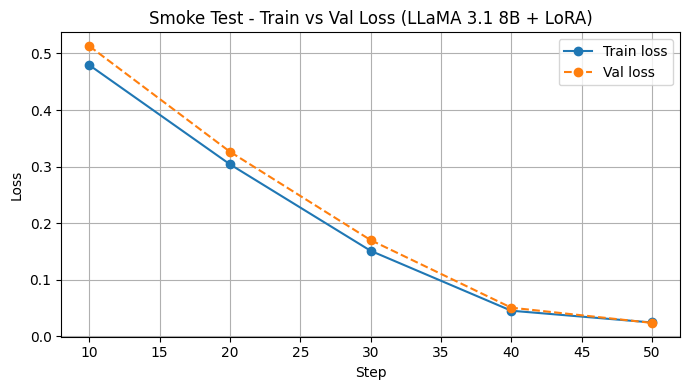

Loss curve saved to results/loss_curve.png


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(history["step"], history["train_loss"], label="Train loss", marker="o")
ax.plot(history["step"], history["val_loss"], label="Val loss", marker="o", linestyle="--")

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Smoke Test - Train vs Val Loss (LLaMA 3.1 8B + LoRA)")
ax.legend()
ax.grid(True)

plt.tight_layout()

# Save to results/
plot_path = RESULTS_DIR / "loss_curve.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"Loss curve saved to {plot_path}")

## 8) Summary
**What this notebook accomplished:**
*   Loaded and documented LLaMA 3.1 8B tokenizer
*   Determined context length T=1024 based on token length analysis
* Built supervised fine-tuning data pipeline with prompt masking
*   Loaded LLaMA 3.1 8B in 4-bit quantization with LoRA adapters
* Ran minimal smoke test with decreased loss that is finite and non-exploding  

**What still needs to be done:**
*   Full fine-tuning on the complete 4055 train examples with proper evaluation on the full dev set
*   Run inference and generate SQL predictions on the test set
*   Compute evaluation metrics
*   Compare performance across all four schemas